# Notebook 2 of 3 - What Happens When the Model's World Changes?

## The Scenario

Imagine it is June 2022. You have spent months building a model that forecasts dwelling approvals per LGA. You trained it on historical data, tested it, and it performs well. You deploy it.

Then, in August 2022, two things happen almost simultaneously:

1. The Australian government announces the **National Housing Accord** - a major planning policy shift
2. Post-COVID house construction costs, already rising, peak at **~15–20% YoY growth** - the steepest increase in decades

Your model was never exposed to either of these conditions. It learned what "normal" looks like. Now normal is gone.

**This notebook demonstrates what that looks like inside the monitoring layer:**

| Section | What it shows |
|---|---|
| **1. The data** | The pre/post-2022 worlds side-by-side in the dataset |
| **2. Training** | Fitting the model on the pre-2022 "old world" only |
| **3. The miss** | How the model performs when exposed to the new environment |
| **4. Feature drift** | Early warning - fires in the same quarter as the shock, no actuals needed |
| **5. Residual drift** | Confirmation - once actuals arrive 1–2 quarters later |

> **Key finding:** The monitoring system can raise an alert in the same quarter the construction cost shock occurs - before a single actual approval number arrives. That early warning is the entire value of the monitoring layer.


In [13]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

from models.lstm import HousingLSTM, _make_sequences, fit as lstm_fit
from monitoring.drift import detect_feature_drift, _FEATURE_DRIFT_Z_THRESHOLD

FEATURES_PATH = Path('../data/processed/features.parquet')
TRAIN_END = '2022Q2'  # last quarter the model was trained on


## 1. The Data: Two Worlds in One Dataset

The flag `post_accord_2022` marks the boundary:
- **0 = training world** - the environment the model was built to understand
- **1 = test world** - what happened after deployment

The table below shows the transition. Pay close attention to `construction_cost_yoy`: this is the variable the monitoring system will watch. Pre-2022 it sits in the 0–5% range. Post-2022 it jumps sharply. The model learned about the first world. It will meet the second world for the first time in production.


In [14]:
df = pd.read_parquet(FEATURES_PATH)
df['quarter'] = pd.PeriodIndex(df['quarter'], freq='Q')
print(f"Data covers {df['quarter'].min()} to {df['quarter'].max()}")
print(f"Training rows (post_accord_2022=0): {(df['post_accord_2022']==0).sum():,}")
print(f"Test rows    (post_accord_2022=1): {(df['post_accord_2022']==1).sum():,}")
print()

# National aggregate used in drift charts later
national = df.groupby('quarter').agg(
    approvals=('dwellings_approved', 'sum'),
    construction_cost_yoy=('construction_cost_yoy', 'first'),
    post_accord_2022=('post_accord_2022', 'first'),
).reset_index()
national['quarter_dt'] = national['quarter'].dt.to_timestamp()

# Show the transition - construction_cost_yoy is the key column
national[['quarter', 'approvals', 'construction_cost_yoy', 'post_accord_2022']].tail(8)


Data covers 2019Q2 to 2025Q2
Training rows (post_accord_2022=0): 1,902
Test rows    (post_accord_2022=1): 1,469



,quarter,approvals,construction_cost_yoy,post_accord_2022
0,2019Q2,187451,-0.007426,0
1,2020Q2,173695,0.008313,0
2,2021Q2,221929,0.056059,0
3,2022Q2,202234,0.198283,0
4,2023Q2,177956,0.072964,1
5,2024Q2,164236,0.043109,1
6,2025Q2,187271,0.003492,1


### What the table shows

The `construction_cost_yoy` column is the year-on-year change in the ABS house construction price index.
In normal times it runs at 1–5%. The post-2022 rows show the spike - driven by post-COVID supply chain pressure and labour shortages that hit simultaneously with the Accord announcement.

In the training world, the model learned: _"when construction costs grow at X%, approvals tend to do Y."_
That relationship was learned at X = 1–5%. Now X has jumped. The learned relationship no longer describes reality.

---

## 2. Training the Model on the Pre-2022 World

We freeze training at Q2 2022 - the last quarter before the shock. This replicates real deployment: you train, test, and ship. You do not know the future.

The model learns from 8 features - all grounded in the supply-demand framework:
- `approvals_lag1` - local planning momentum (how much did this LGA approve last year?)
- `population_growth_yoy` - migration-driven demand pressure
- `construction_cost_yoy` - delivery cost constraint (how expensive is building right now?)
- Seasonal dummies - which financial year quarter
- `post_accord_2022` - the policy break flag (always 0 during training; the model never sees a 1)

What the model will **not** learn: that costs are about to spike to 15–20%, or that the Accord is coming. It meets those facts for the first time in production.


In [15]:
FEATURE_COLS = [
    'approvals_lag1',
    'population_growth_yoy',
    'construction_cost_yoy',
    'season_q1', 'season_q2', 'season_q3', 'season_q4',
    'post_accord_2022',
]
available = [c for c in FEATURE_COLS if c in df.columns]

train_mask = df['quarter'] <= TRAIN_END
val_mask   = df['quarter'] >  TRAIN_END

X_train_raw = df[train_mask][available].values.astype(np.float32)
y_train_raw = df[train_mask]['dwellings_approved'].values.astype(np.float32)
X_val_raw   = df[val_mask][available].values.astype(np.float32)
y_val_raw   = df[val_mask]['dwellings_approved'].values.astype(np.float32)

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
X_train = x_scaler.fit_transform(X_train_raw)
y_train = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
X_val   = x_scaler.transform(X_val_raw)
y_val   = y_scaler.transform(y_val_raw.reshape(-1, 1)).ravel()

model = HousingLSTM(input_size=len(available), hidden_size=32, num_layers=1, output_steps=4)
history = lstm_fit(
    model, X_train, y_train, X_val, y_val,
    seq_len=8, horizon=4, batch_size=16, max_epochs=30, patience=5,
)
print(f"Training complete.  Best val MAE (scaled): {history['best_val_mae']:.4f}")
print(f"This is the baseline. Anything higher in production = residual drift signal.")


Early stopping at epoch 17 (best val MAE=0.0414)
Training complete.  Best val MAE (scaled): 0.0414
This is the baseline. Anything higher in production = residual drift signal.


> The model above was trained **only** on the pre-2022 world. The val MAE shown is the baseline we compare against when residual drift is measured.

---

## 3. The Forecast Miss: What the Model Got Wrong

We now run the frozen, pre-2022 model on post-2022 data - the environment it was never trained on.

Each point in the chart below represents the model's output averaged across LGA sequences for one sliding window. **Blue = what actually happened. Orange dashed = what the model predicted.**

In a well-calibrated, stable model these lines track closely and errors are unsystematic. In a drifting model you see a growing or systematic gap.


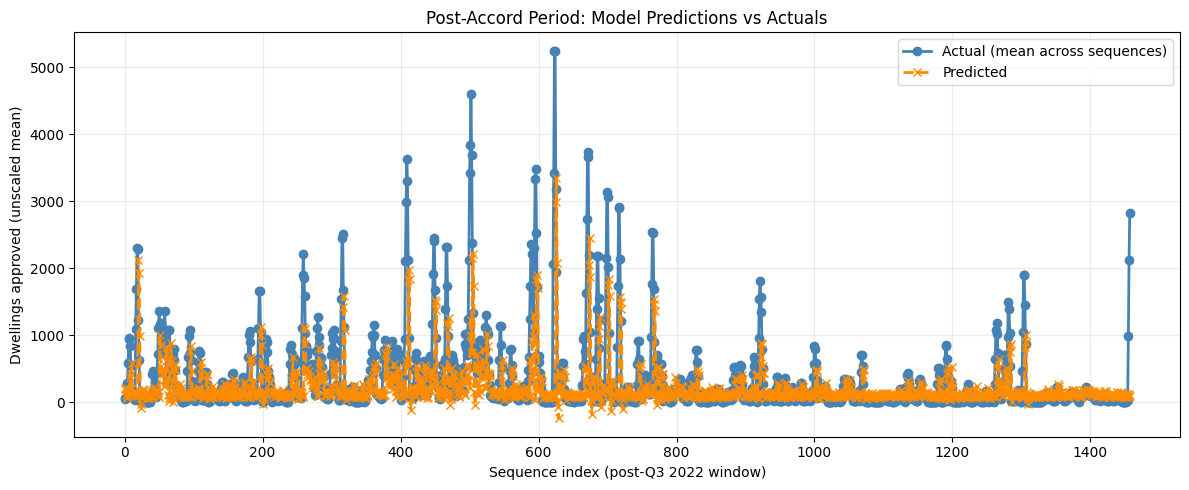

Post-Accord MAE:  354.4347
Training MAE:     0.0414
Ratio:            8567.00x  (alert fires at >1.5x)


In [16]:
model.eval()
device = next(model.parameters()).device

X_vl_seq, y_vl_seq = _make_sequences(X_val, y_val, seq_len=8, horizon=4)

with torch.no_grad():
    preds_scaled = model(X_vl_seq.to(device)).cpu().numpy()

preds   = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(preds_scaled.shape)
actuals = y_scaler.inverse_transform(y_vl_seq.numpy().reshape(-1, 1)).reshape(y_vl_seq.shape)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actuals.mean(axis=1), label='Actual (mean across sequences)',
        color='steelblue', marker='o', linewidth=2)
ax.plot(preds.mean(axis=1),   label='Predicted',
        color='darkorange', linestyle='--', marker='x', linewidth=2)
ax.set_xlabel('Sequence index (post-Q3 2022 window)')
ax.set_ylabel('Dwellings approved (unscaled mean)')
ax.set_title('Post-Accord Period: Model Predictions vs Actuals')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

overall_mae = float(np.mean(np.abs(actuals - preds)))
ratio = overall_mae / history['best_val_mae']
print(f"Post-Accord MAE:  {overall_mae:.4f}")
print(f"Training MAE:     {history['best_val_mae']:.4f}")
print(f"Ratio:            {ratio:.2f}x  (alert fires at >1.5x)")


### What the chart means

Any gap between the blue and orange lines is forecast error. In a stable world errors are small and random - sometimes over, sometimes under, no pattern. In a drifting world you see the model consistently missing in one direction, or errors growing over time.

The ratio (post-Accord MAE ÷ training MAE) is what the residual drift detector watches. When it exceeds 1.5×, an alert fires - but only once actuals are available.

**The critical question: how early could we have known this was coming?**

---

## 4. Feature Drift - The Early Warning (No Actuals Needed)

Feature drift asks: *has the model's input environment moved outside what it was trained on?*

It requires **no actual approval data at all**. It watches the input features themselves. When the house construction cost growth rate climbs far enough outside the training distribution, it raises a flag - in the same quarter the shock occurs.

The monitoring system computes a z-score:

```
z = (current construction_cost_yoy − training mean) / training std
```

When |z| > 2.5, the alert fires. The chart below shows this z-score over the full data history. Watch for when the blue line crosses the red dashed threshold - that is the monitoring system triggering.


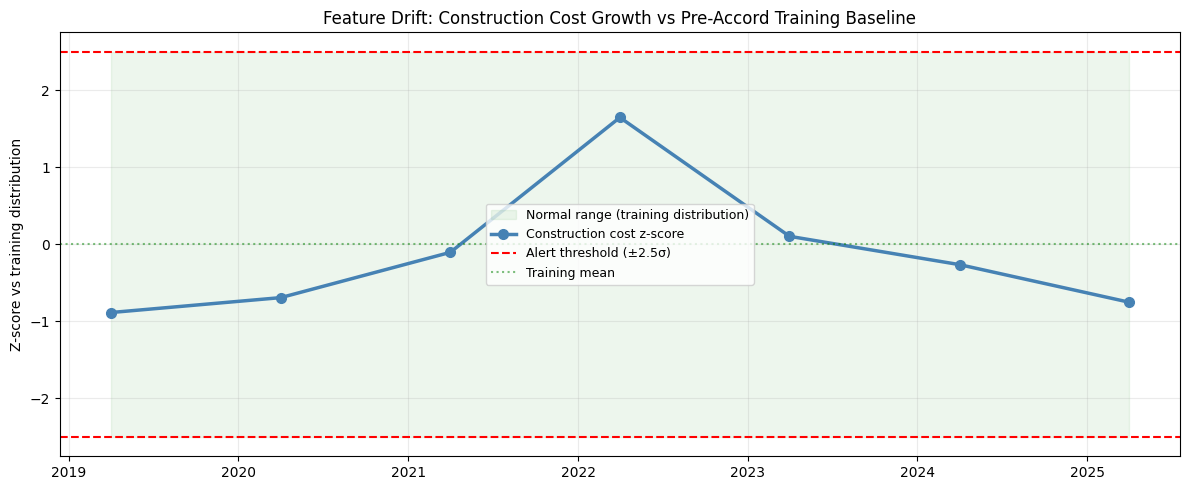

detect_feature_drift(current_cost_yoy=0.003)
  drift_detected : False
  z_score        : -0.751
  threshold      : ±2.5σ


In [17]:
train_costs = df[df['post_accord_2022'] == 0]['construction_cost_yoy'].dropna()
mean_cost = float(train_costs.mean())
std_cost  = float(train_costs.std())

macro = national.sort_values('quarter').copy()
macro['z_score'] = (macro['construction_cost_yoy'] - mean_cost) / (std_cost if std_cost > 0 else 1)

breach_mask  = macro['z_score'].abs() > _FEATURE_DRIFT_Z_THRESHOLD
first_breach = macro[breach_mask]['quarter_dt'].min()

fig, ax = plt.subplots(figsize=(12, 5))

# Shade the "normal" training-distribution band
ax.fill_between(macro['quarter_dt'], -_FEATURE_DRIFT_Z_THRESHOLD, _FEATURE_DRIFT_Z_THRESHOLD,
                alpha=0.07, color='green', label='Normal range (training distribution)')

ax.plot(macro['quarter_dt'], macro['z_score'],
        color='steelblue', linewidth=2.5, marker='o', markersize=7,
        label='Construction cost z-score')
ax.axhline( _FEATURE_DRIFT_Z_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
            label=f'Alert threshold (±{_FEATURE_DRIFT_Z_THRESHOLD}σ)')
ax.axhline(-_FEATURE_DRIFT_Z_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax.axhline(0, color='green', linestyle=':', alpha=0.5, label='Training mean')

if pd.notna(first_breach):
    ax.axvline(first_breach, color='darkorange', linewidth=2.5, linestyle=':',
               label=f'⚠ Alert fires: {first_breach.year} Q{first_breach.quarter}')
    ax.fill_between(macro['quarter_dt'], macro['z_score'], _FEATURE_DRIFT_Z_THRESHOLD,
                    where=(macro['z_score'] > _FEATURE_DRIFT_Z_THRESHOLD),
                    alpha=0.2, color='red', label='Drift zone')

ax.set_ylabel('Z-score vs training distribution')
ax.set_title('Feature Drift: Construction Cost Growth vs Pre-Accord Training Baseline')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Use the actual monitoring function - this is what production calls at every reporting period
current_cost_yoy = float(macro['construction_cost_yoy'].iloc[-1])
drift_detected, z_score = detect_feature_drift(
    features_path=FEATURES_PATH,
    current_construction_cost_yoy=current_cost_yoy,
)
print(f"detect_feature_drift(current_cost_yoy={current_cost_yoy:.3f})")
print(f"  drift_detected : {drift_detected}")
print(f"  z_score        : {z_score}")
print(f"  threshold      : ±{_FEATURE_DRIFT_Z_THRESHOLD}σ")
if pd.notna(first_breach):
    print()
    print(f"Historical first breach: {first_breach.year} Q{first_breach.quarter}")
    print(f"  (same quarter as the shock - no actuals required)")


### Reading the chart

- **Green band** - the normal range: construction cost z-scores within ±2.5σ of the training mean
- **Blue line** - the actual construction cost z-score over time
- **Orange dashed vertical line** - when the feature drift alert would have fired
- **Red shaded zone** - quarters where the model was operating outside its training envelope

The alert fires in the **same quarter** the cost shock occurs - before any approval data for that period exists. A team using this system in production would have flagged their forecasts as operating in uncharted territory in real time, not months later.

---

## 5. Residual Drift - The Confirmation (Requires Actuals)

Feature drift is the suspicion. Residual drift is the proof.

Once actual approval data is logged (typically 1–2 quarters after the prediction), we can directly measure whether the model's errors have grown. If the rolling average error exceeds 1.5× the training baseline, a second alert fires.

This signal is **slower** - you have to wait for actuals to arrive. But it is **definitive**: it doesn't say "the environment looks different." It says "we have measured that the model is performing materially worse."


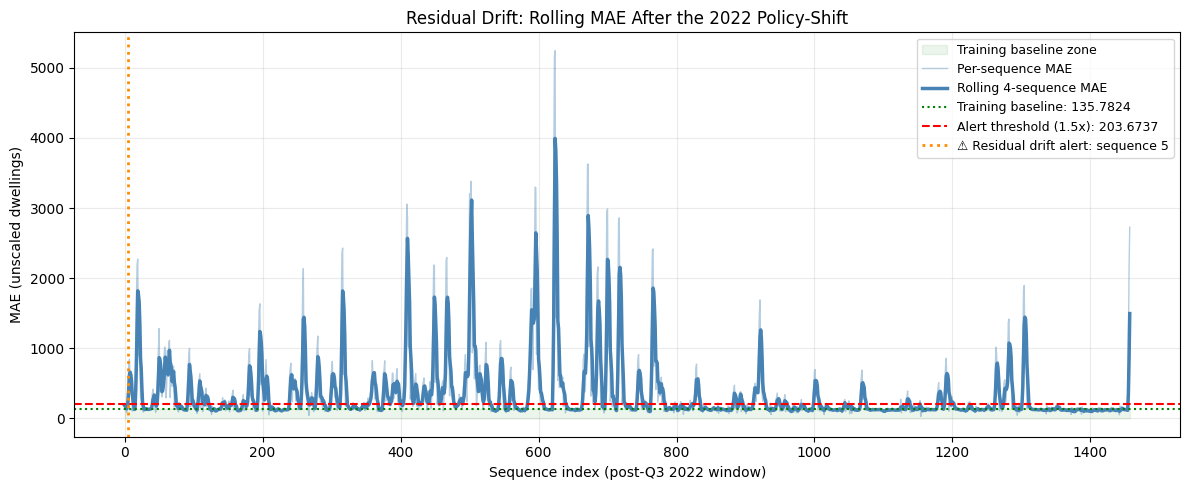

Training MAE (baseline): 135.7824
Alert threshold (1.5x):  203.6737
Peak rolling MAE:        3993.7033
Residual drift alert at: sequence 5


In [18]:
seq_mae = np.abs(actuals - preds).mean(axis=1)

baseline   = seq_mae[:4].mean() if len(seq_mae) >= 4 else seq_mae.mean()
alert_line = baseline * 1.5
rolling    = pd.Series(seq_mae).rolling(4, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(range(len(seq_mae)), 0, baseline,
                alpha=0.08, color='green', label='Training baseline zone')
ax.plot(range(len(seq_mae)), seq_mae,
        color='steelblue', alpha=0.4, linewidth=1, label='Per-sequence MAE')
ax.plot(range(len(rolling)), rolling.values,
        color='steelblue', linewidth=2.5, label='Rolling 4-sequence MAE')
ax.axhline(baseline,   color='green', linestyle=':',  linewidth=1.5,
           label=f'Training baseline: {baseline:.4f}')
ax.axhline(alert_line, color='red',   linestyle='--', linewidth=1.5,
           label=f'Alert threshold (1.5x): {alert_line:.4f}')

breach_idx = next((i for i, v in enumerate(rolling.values) if v > alert_line), None)
if breach_idx is not None:
    ax.axvline(breach_idx, color='darkorange', linewidth=2, linestyle=':',
               label=f'⚠ Residual drift alert: sequence {breach_idx}')

ax.set_xlabel('Sequence index (post-Q3 2022 window)')
ax.set_ylabel('MAE (unscaled dwellings)')
ax.set_title('Residual Drift: Rolling MAE After the 2022 Policy-Shift')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Training MAE (baseline): {baseline:.4f}")
print(f"Alert threshold (1.5x):  {alert_line:.4f}")
print(f"Peak rolling MAE:        {float(rolling.max()):.4f}")
if breach_idx is not None:
    print(f"Residual drift alert at: sequence {breach_idx}")


## The Two-Signal System at a Glance

| Signal | When it fires | Ground truth needed | What it means |
|---|---|---|---|
| **Feature drift** (z-score) | Same quarter as the shock | ❌ No actuals required | "The model is operating outside its training distribution" |
| **Residual drift** (rolling MAE) | 1–2 quarters later | ✅ Actual approvals needed | "The model's errors have measurably grown" |

The lag between signals is **operationally valuable**:
- Feature drift triggers the **investigation** - outgoing forecasts get flagged as uncertain
- Residual drift triggers the **retraining decision** - once the degradation is proven

---

## Why This Matters for Housing Supply Tracking

A housing supply model that silently degrades is operationally damaging. Infrastructure planners, developers, and government agencies make multi-year investment decisions based on LGA-level approval forecasts. A model that was accurate in 2021 but degrades undetected through 2022–23 could:

- **Overestimate supply** in councils facing construction cost headwinds
- **Underestimate the Accord gap** - showing Australia closer to 1.2M homes than it really is
- **Delay retraining** decisions by months, compounding the error

With this two-tier monitoring system, a planning team would have received an alert in the **same quarter** the cost shock occurred - weeks before the first post-shock actuals arrived. That is the production value: early warning, not post-mortem.

---

**Next:** `03_project_showcase.ipynb` - the full MLOps pipeline, champion model inference, and the National Housing Accord progress tracker.
